[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch11_workbook.ipynb)

# Scaling laws and emergent abilities

The fitted pre-training loss of a language model is a constant plus one term
that shrinks as a power of its parameter count and one that shrinks as a power
of its training tokens, and a fixed compute budget buys more of one only by
buying less of the other. When every token of an answer is right
independently and with the same accuracy, a score that counts the answer right
only when every token is right is that accuracy raised to the answer's length.

In [1]:
#@title Setup: run this cell first
import math

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

# The parametric loss L(N, D) = E + A / N^α + B / D^β in nats per token, fitted by Hoffmann
# et al. 2022, "Training Compute-Optimal Large Language Models", as their approach 3, with the
# constants of Besiroglu et al. 2024's refit, "Chinchilla Scaling: A replication attempt", Table 1.
E, A, B, ALPHA, BETA = 1.8172, 482.01, 2085.43, 0.3478, 0.3658
FIT = (70e6, 16e9)  # Hoffmann's fitted runs: 70 million to over 16 billion parameters (abstract)
TOKENS = (5e9, 500e9)  # and 5 to 500 billion tokens (Hoffmann et al. 2022, abstract)
RATIO = 20  # tokens per parameter in approach 1's projections (Hoffmann et al. 2022, Table 3)
BASE = 1e9  # the 1B run, 10^9 parameters on 20 × 10^9 tokens (Hoffmann et al. 2022, Table 3)
GRID = np.arange(0.5, 0.96, 0.05).round(2)  # per-token accuracies drawn, 0.5 to 0.95


# A setting a cell refuses: Colab prints the one sentence, without the stack.
class Refused(Exception):
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


# One sentence naming the setting, its value (cut at 40 characters, with an ellipsis) and the rule.
def refuse(name, value, rule):
    shown = repr(value) if len(repr(value)) <= 40 else repr(value)[:39] + "…"
    raise Refused(f"{name} is {shown}, of type {type(value).__name__}: {name} takes {rule}.")


# The setting as a float when it is a number from low to high, a whole number where whole.
def need(name, value, low, high, what, whole=False):
    ok = isinstance(value, (int, np.integer) if whole else (int, float, np.integer, np.floating))
    if isinstance(value, bool) or not ok or not low <= value <= high:
        refuse(name, value, f"{what} from {num(low)} to {num(high)}")
    return float(value)


# x to three significant figures; from 1,000 up and below 0.001 as a mantissa times a power of ten.
def num(x):
    m, e = f"{x:.2e}".split("e")
    sup = str(int(e)).translate(str.maketrans("-0123456789", "⁻⁰¹²³⁴⁵⁶⁷⁸⁹"))
    return f"{x:.3g}" if x == 0 or 1e-3 <= abs(x) < 999.5 else f"{float(m):g} × 10{sup}"


# The constant E, the parameter term A / N^α and the data term B / D^β.
def terms(N, D):
    return E, A / N ** ALPHA, B / D ** BETA


def loss(N, D):
    return sum(terms(N, D))


# The fit's lowest loss at C ≈ 6ND: N_opt = G (C/6)^a, D_opt = (C/6)^b / G (Hoffmann, eq. 4).
def frontier(C):
    N = (ALPHA * A / (BETA * B)) ** (1 / (ALPHA + BETA)) * (C / 6) ** (BETA / (ALPHA + BETA))
    return N, C / 6 / N


def where(N, D):
    side = "inside" if FIT[0] <= N <= FIT[1] and TOKENS[0] <= D <= TOKENS[1] else "outside"
    return (f"{num(N)} parameters on {num(D)} tokens lie {side} the fitted runs, {num(FIT[0])} to "
            f"{num(FIT[1])} parameters on {num(TOKENS[0])} to {num(TOKENS[1])} tokens")


# The fit's loss at twenty tokens per parameter against model size, with N marked.
def curve(N):
    xs, y = np.logspace(6, math.log10(max(1e13, N * 10))), loss(N, RATIO * N)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.axvspan(max(FIT[0], TOKENS[0] / RATIO), min(FIT[1], TOKENS[1] / RATIO), fc="0.92",
               hatch="//", ec="0.75", label="fitted runs, at twenty tokens per parameter")
    ax.plot(xs, loss(xs, RATIO * xs), "-", label="predicted loss, twenty tokens per parameter")
    ax.axhline(E, color="gray", ls="--", label=f"constant E = {E}")
    ax.plot(N, y, "o", color="black")
    ax.annotate(f"{y:.3f}", (N, y), xytext=(6, 6), textcoords="offset points", fontsize=9)
    ax.set(xscale="log", xlabel="parameters N (log scale)", ylabel="loss, nats per token",
           ylim=(0, 1.1 * loss(xs[0], RATIO * xs[0])))
    ax.legend(fontsize=8, loc="upper right")
    plt.show()


# The 1B run, the run with DOUBLE's quantity doubled, and the run with the other one doubled.
def runs(pick):
    if not (isinstance(pick, str) and pick.strip().lower() in ("data", "model")):
        refuse("DOUBLE", pick, '"data" or "model"')
    twice = {"data doubled": (BASE, 2 * RATIO * BASE), "model doubled": (2 * BASE, RATIO * BASE)}
    first = pick.strip().lower() + " doubled"
    return {"1B run": (BASE, RATIO * BASE), first: twice.pop(first), **twice}


# The 1B run and the doubled run as stacked bars of the three terms, each term and total labelled.
def doubling(pick):
    named, bottom = list(runs(pick).items())[:2], np.zeros(2)
    parts = np.array([terms(*nd) for _, nd in named])
    fig, ax = plt.subplots(figsize=(6, 3.5))
    for k, name in enumerate(["constant E", "parameter term A / N^α", "data term B / D^β"]):
        bars = ax.bar(range(2), parts[:, k], 0.5, bottom=bottom, hatch=["xx", "//", ".."][k],
                      ec="black", label=name)
        ax.bar_label(bars, fmt="%.3f", label_type="center", fontsize=8, bbox=dict(fc="w", lw=0))
        bottom += parts[:, k]
    ax.bar_label(bars, labels=[f"{v:.3f}" for v in bottom], padding=2, fontsize=9)
    ax.set_xticks(range(2), [f"{k}\n{num(n)} parameters\n{num(d)} tokens" for k, (n, d) in named])
    ax.set(ylabel="loss, nats per token", ylim=(0, 1.15 * bottom.max()))
    ax.legend(fontsize=8, ncol=3, loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False)
    plt.show()


# Per-token accuracy beside exact match on k tokens, each exact-match bar labelled.
def exact_bars(k):
    x, em = np.arange(len(GRID)), [p ** k for p in GRID]
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(x - 0.2, GRID, 0.4, color="0.85", hatch="//", ec="0.4", label="per-token accuracy p")
    bars = ax.bar(x + 0.2, em, 0.4, color="tab:blue", ec="k", label=f"exact match, length {k:.0f}")
    ax.bar_label(bars, labels=[f"{v:.2f}" if v >= 0.01 else f"{v:.1e}" for v in em], padding=2,
                 fontsize=8, rotation=90)
    ax.set_xticks(x, [f"{p:g}" for p in GRID])
    ax.set(xlabel="per-token accuracy p", ylabel="share right, per token or answer", ylim=(0, 1.3))
    ax.legend(fontsize=8, loc="upper left")
    plt.show()


display(Markdown(f"L(N, D) = {E} + {A} / N^{ALPHA} + {B} / D^{BETA} nats per token; C ≈ 6ND."))

L(N, D) = 1.8172 + 482.01 / N^0.3478 + 2085.43 / D^0.3658 nats per token; C ≈ 6ND.

## 1. The predicted loss at twenty tokens per parameter

A model of `PARAMS` parameters trained on twenty tokens per parameter has the
loss the parametric fit predicts; run the cell, then set `PARAMS = 1e11` and
run it again. What loss does the fit predict at each size, and how much of it
would no model size remove?

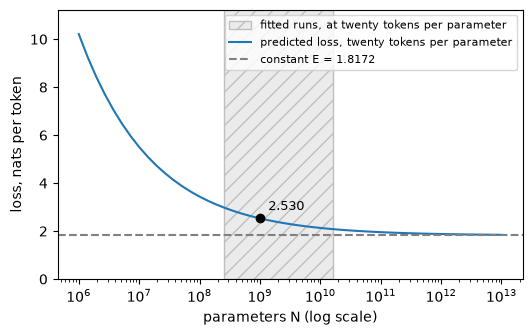

In [2]:
PARAMS = 1e9
curve(need("PARAMS", PARAMS, 1e6, 1e15, "a number of parameters"))

### Solution

In [3]:
N = need("PARAMS", PARAMS, 1e6, 1e15, "a number of parameters")
e, p, d = terms(N, RATIO * N)
display(Markdown(f"A model of {num(N)} parameters on {num(RATIO * N)} tokens costs 6ND = "
                 f"{num(6 * N * RATIO * N)} FLOPs, and the fit predicts {e + p + d:.3f} nats per "
                 f"token: {e} from the constant E, which no model size removes, {p:.3f} from the "
                 f"parameter term and {d:.3f} from the data term. {where(N, RATIO * N)}."))

A model of 1 × 10⁹ parameters on 2 × 10¹⁰ tokens costs 6ND = 1.2 × 10²⁰ FLOPs, and the fit predicts 2.530 nats per token: 1.8172 from the constant E, which no model size removes, 0.357 from the parameter term and 0.356 from the data term. 1 × 10⁹ parameters on 2 × 10¹⁰ tokens lie inside the fitted runs, 7 × 10⁷ to 1.6 × 10¹⁰ parameters on 5 × 10⁹ to 5 × 10¹¹ tokens.

## 2. Twice the data or twice the model at the same compute

A model of a billion parameters trained on twenty billion tokens can spend
twice its compute on twice the data or on twice the parameters, and `DOUBLE`
names the doubled quantity; run the cell, then set `DOUBLE = "model"` and run
it again. Which doubling lowers the predicted loss more, and which term of the
loss does each one shrink?

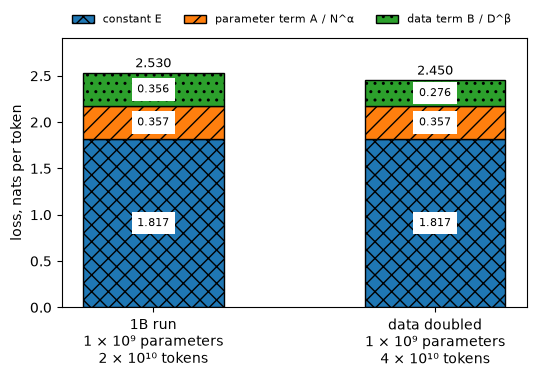

In [4]:
DOUBLE = "data"
doubling(DOUBLE)

### Solution

In [5]:
# Losses rounded as printed, so each drop is the difference of the two losses beside it.
L0, L1, L2 = [round(loss(*nd), 3) for nd in runs(DOUBLE).values()]
mine, theirs = [k.split()[0] for k in runs(DOUBLE)][1:]


# The drops from doubling the data and the model at n parameters on 20n tokens, to three decimals.
def verdict(n):
    r = RATIO * n
    dd, dm = round(loss(n, r) - loss(n, 2 * r), 3), round(loss(n, r) - loss(2 * n, r), 3)
    same = ", equal to three decimals" if dd == dm else ""
    return f"{dd:.3f} for the data and {dm:.3f} for the model at {num(n)} parameters{same}"


display(Markdown(
    f"Both doublings cost {num(2 * 6 * BASE * RATIO * BASE)} FLOPs, twice the 1B run. Doubling "
    f"the {mine} lowers the loss from {L0:.3f} to {L1:.3f} nats, by {L0 - L1:.3f}, and doubling "
    f"the {theirs} lowers it to {L2:.3f}, by {L0 - L2:.3f}; doubling the data shrinks the data "
    f"term alone and doubling the model the parameter term alone. At twenty tokens per parameter "
    f"and the ends of the fitted sizes, the drops are {verdict(FIT[0])}, and {verdict(FIT[1])}."))

Both doublings cost 2.4 × 10²⁰ FLOPs, twice the 1B run. Doubling the data lowers the loss from 2.530 to 2.450 nats, by 0.080, and doubling the model lowers it to 2.454, by 0.076; doubling the data shrinks the data term alone and doubling the model the parameter term alone. At twenty tokens per parameter and the ends of the fitted sizes, the drops are 0.211 for the data and 0.193 for the model at 7 × 10⁷ parameters, and 0.029 for the data and 0.029 for the model at 1.6 × 10¹⁰ parameters, equal to three decimals.

## 3. Exact match multiplies the accuracy of every token

An answer of `LENGTH` tokens counts as right only when every token is right.
With each token right independently and with the same per-token accuracy p,
exact match is p raised to `LENGTH`, so a smooth rise in p can produce a late
jump in exact match, the shape of the benchmark curves reported as emergent
abilities. Run the cell, then set `LENGTH = 1` and then
`LENGTH = 100`: as per-token accuracy rises in equal steps, how does exact
match rise, and at what per-token accuracy does it reach one half?

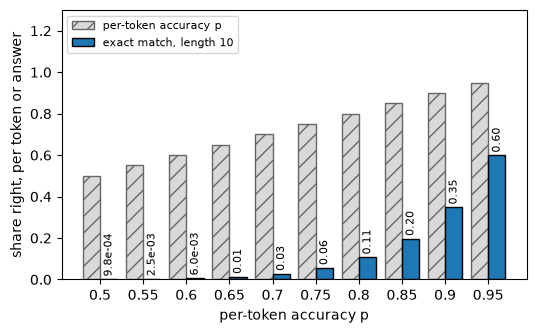

In [6]:
LENGTH = 10
exact_bars(need("LENGTH", LENGTH, 1, 100, "a whole number of tokens", whole=True))

### Solution

In [7]:
k = need("LENGTH", LENGTH, 1, 100, "a whole number of tokens", whole=True)
display(Markdown(
    f"On an answer of length {k:.0f}, per-token accuracy rising from 0.5 to 0.9, a factor of "
    f"{0.9 / 0.5:.1f}, lifts exact match from {num(0.5 ** k)} to {num(0.9 ** k)}, a factor of "
    f"{num(0.9 ** k / 0.5 ** k)}; at 0.99 it is {num(0.99 ** k)}. Exact match reaches one half "
    f"at p = 0.5^(1/{k:.0f}) = {0.5 ** (1 / k):.3f}."))

On an answer of length 10, per-token accuracy rising from 0.5 to 0.9, a factor of 1.8, lifts exact match from 9.77 × 10⁻⁴ to 0.349, a factor of 357; at 0.99 it is 0.904. Exact match reaches one half at p = 0.5^(1/10) = 0.933.

## Appendix. The fitted loss surface and the compute-optimal size

Hoffmann et al. fitted, as the third of their three approaches, a parametric
loss for a model of N parameters trained on D tokens, in nats per token,

L(N, D) = E + A / N^α + B / D^β,

and Besiroglu et al. refitted it to E = 1.8172, A = 482.01, B = 2085.43,
α = 0.3478 and β = 0.3658. Hoffmann's printed constants put the
compute-optimal ratio of tokens to parameters rising with compute, and the
refit puts it near 20, as Hoffmann's approaches 1 and 2 do.

E is the loss that no size removes; the second term shrinks as the model
grows and the third as the data grows. Training costs C ≈ 6ND FLOPs, so a
fixed budget fixes the product ND, and a larger model sees fewer tokens.
Along a line of fixed C the loss is lowest where α A / N^α = β B / D^β, at

N_opt(C) = G (C/6)^a,  D_opt(C) = (C/6)^b / G,  with a = β / (α + β), b = α / (α + β)
and G = (α A / (β B))^(1/(α + β)).

Twenty tokens per parameter, D = 20N, makes C = 120 N², so N = √(C/120).

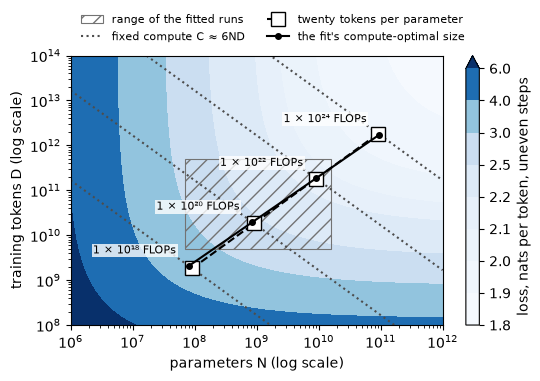

In [8]:
Ns, Ds, Cs = np.logspace(6, 12, 200), np.logspace(8, 14, 200), 10.0 ** np.arange(18, 25, 2)
fig, ax = plt.subplots(figsize=(6, 3.5))
fig.colorbar(ax.contourf(Ns, Ds, loss(*np.meshgrid(Ns, Ds)), [1.8, 1.9, 2, 2.1, 2.2, 2.5, 3, 4, 6],
                         cmap="Blues", extend="max"), label="loss, nats per token, uneven steps")
ax.add_patch(plt.Rectangle((FIT[0], TOKENS[0]), FIT[1] - FIT[0], TOKENS[1] - TOKENS[0], fill=False,
                           hatch="//", ec="0.45", lw=0.8, label="range of the fitted runs"))
for C in Cs:
    ax.plot(Ns, C / 6 / Ns, ":", c="0.3", label="fixed compute C ≈ 6ND" if C == Cs[0] else None)
    ax.annotate(f"{num(C)} FLOPs", frontier(C), xytext=(-9, 9), textcoords="offset points",
                ha="right", fontsize=8, bbox=dict(fc="white", ec="none", alpha=0.8, pad=1))
ax.plot(np.sqrt(Cs / 120), RATIO * np.sqrt(Cs / 120), "--s", c="k", mfc="w", ms=10,
        label="twenty tokens per parameter")
ax.plot(*frontier(Cs), "-o", c="k", ms=4, label="the fit's compute-optimal size")
ax.set(xscale="log", yscale="log", xlabel="parameters N (log scale)",
       ylabel="training tokens D (log scale)", xlim=(Ns[0], Ns[-1]), ylim=(Ds[0], Ds[-1]))
ax.legend(fontsize=8, ncol=2, loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False)
plt.show()

**Exercise.** Set `BUDGET` to 1e20, 1e23 and 1e25 FLOPs in turn and rerun the
cell. How many parameters and tokens does the fit's optimum give at each
budget, against twenty tokens per parameter, and by what power of the budget
do the optimal parameters and tokens grow?

In [9]:
BUDGET = 1e23

n, d = frontier(need("BUDGET", BUDGET, 1e15, 1e30, "a number of FLOPs"))
m = math.sqrt(BUDGET / 120)
print(f"Optimum: {num(n)} parameters, {num(d)} tokens, {d / n:.1f} per parameter, "
      f"loss {loss(n, d):.3f}; {where(n, d)}.")
print(f"20 per parameter: {num(m)} parameters, {num(20 * m)} tokens, loss {loss(m, 20 * m):.3f}.")

Optimum: 2.94 × 10¹⁰ parameters, 5.66 × 10¹¹ tokens, 19.2 per parameter, loss 2.032; 2.94 × 10¹⁰ parameters on 5.66 × 10¹¹ tokens lie outside the fitted runs, 7 × 10⁷ to 1.6 × 10¹⁰ parameters on 5 × 10⁹ to 5 × 10¹¹ tokens.
20 per parameter: 2.89 × 10¹⁰ parameters, 5.77 × 10¹¹ tokens, loss 2.032.


### Solution

In [10]:
Cs = 10.0 ** np.arange(18, 27)
rows = [(C, *frontier(C), math.sqrt(C / 120)) for C in Cs]
lines = [f"| {num(C)} | {num(n)} | {num(d)} | {d / n:.1f} | {loss(n, d):.3f} | {num(m)} | "
         f"{loss(m, RATIO * m):.3f} |" for C, n, d, m in rows]
display(Markdown("| C, FLOPs | N_opt | D_opt | D_opt/N_opt | loss | N at 20 per parameter | loss |"
                 "\n" + "| ---: " * 7 + "|\n" + "\n".join(lines)))
a, b = [math.log10(rows[-1][i] / rows[0][i]) / math.log10(Cs[-1] / Cs[0]) for i in (1, 2)]
# The gap between the two loss columns, each rounded as the table prints it.
gap = [round(loss(m, RATIO * m), 3) - round(loss(n, d), 3) for C, n, d, m in rows]
display(Markdown(
    f"At the refit's point estimates the optimal parameters grow as C^{a:.3f} and the tokens as "
    f"C^{b:.3f}, by {10 ** a:.2f} and {10 ** b:.2f} per tenfold budget, and the tokens per "
    f"parameter go from {rows[0][2] / rows[0][1]:.1f} at {num(Cs[0])} FLOPs to "
    f"{rows[-1][2] / rows[-1][1]:.1f} at {num(Cs[-1])}. Besiroglu et al. give a standard error of "
    f"0.02 on a, against a − 0.5 = {a - 0.5:.3f}; twenty tokens per parameter grows both by "
    f"{10 ** 0.5:.2f} per tenfold budget. The loss columns differ by {min(gap):.3f} to "
    f"{max(gap):.3f} nats."))

| C, FLOPs | N_opt | D_opt | D_opt/N_opt | loss | N at 20 per parameter | loss |
| ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| 1 × 10¹⁸ | 8.05 × 10⁷ | 2.07 × 10⁹ | 25.7 | 3.490 | 9.13 × 10⁷ | 3.492 |
| 1 × 10¹⁹ | 2.62 × 10⁸ | 6.36 × 10⁹ | 24.2 | 2.927 | 2.89 × 10⁸ | 2.928 |
| 1 × 10²⁰ | 8.53 × 10⁸ | 1.95 × 10¹⁰ | 22.9 | 2.553 | 9.13 × 10⁸ | 2.554 |
| 1 × 10²¹ | 2.78 × 10⁹ | 6 × 10¹⁰ | 21.6 | 2.306 | 2.89 × 10⁹ | 2.306 |
| 1 × 10²² | 9.05 × 10⁹ | 1.84 × 10¹¹ | 20.4 | 2.141 | 9.13 × 10⁹ | 2.141 |
| 1 × 10²³ | 2.94 × 10¹⁰ | 5.66 × 10¹¹ | 19.2 | 2.032 | 2.89 × 10¹⁰ | 2.032 |
| 1 × 10²⁴ | 9.59 × 10¹⁰ | 1.74 × 10¹² | 18.1 | 1.960 | 9.13 × 10¹⁰ | 1.960 |
| 1 × 10²⁵ | 3.12 × 10¹¹ | 5.34 × 10¹² | 17.1 | 1.912 | 2.89 × 10¹¹ | 1.912 |
| 1 × 10²⁶ | 1.02 × 10¹² | 1.64 × 10¹³ | 16.1 | 1.880 | 9.13 × 10¹¹ | 1.880 |

At the refit's point estimates the optimal parameters grow as C^0.513 and the tokens as C^0.487, by 3.26 and 3.07 per tenfold budget, and the tokens per parameter go from 25.7 at 1 × 10¹⁸ FLOPs to 16.1 at 1 × 10²⁶. Besiroglu et al. give a standard error of 0.02 on a, against a − 0.5 = 0.013; twenty tokens per parameter grows both by 3.16 per tenfold budget. The loss columns differ by 0.000 to 0.002 nats.